In [ ]:
# Execute first
import os
FIG_ROOT = os.environ.get('SCDIS_FIG', os.path.join(os.environ['SCDIS_ROOT'], 'figures'))

In [1]:
import scanpy as sc
import anndata as ad
from scipy.stats import ttest_ind, ttest_rel
import matplotlib.pyplot as plt

In [2]:
import matplotlib

matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Liberation Sans'
matplotlib.rcParams['mathtext.default'] = 'regular'
matplotlib.rcParams['axes.unicode_minus'] = False

In [3]:
import os
os.makedirs(f'{FIG_ROOT}/Myocarditis', exist_ok=True)

In [4]:
def subsample_anndata_equal(adata, label_col="y", random_state=42):
    # Find smallest group size
    min_cells = adata.obs[label_col].value_counts().min()
    
    sampled_indices = (
        adata.obs.groupby(label_col)
        .apply(lambda x: x.sample(min_cells, random_state=random_state))
        .index.get_level_values(1)
    )
    
    return adata[sampled_indices].copy(), sampled_indices

In [5]:
preds_path = '../../Benchmarks/SCDISENTANGLE/Myocarditis/predictions/myocarditis'

In [6]:
donors = [
     'SIC_264',
     'SIC_258',
     'SIC_199',
     'SIC_48',
     'SIC_177',
     'SIC_232',
     'SIC_164',
     'SIC_217',
     'SIC_153',
     'SIC_175',
     'SIC_171'
]

# Read and normalize original data

In [7]:
adata_org = sc.read_h5ad('../../Datasets/preprocessed_datasets/myocarditis.h5ad')
adata_org = adata_org[adata_org.obs['donor'] != 'SIC_197'].copy()
sc.pp.normalize_total(adata_org)
sc.pp.log1p(adata_org)

adata.X seems to be already log-transformed.


# Concat predictions for all donors

In [8]:
adata_pred_cat = []
for donor in donors:
    _adata = sc.read_h5ad(f'{preds_path}/{donor}_1.h5ad')
    adata_pred_cat.append(_adata)
adata_pred_cat = ad.concat(adata_pred_cat)

/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:18

# Normalize predictions

In [9]:
sc.pp.normalize_total(adata_pred_cat)
sc.pp.log1p(adata_pred_cat)

# Subset to predicted heart cells from blood cells

In [10]:
pred_heart = adata_pred_cat[adata_pred_cat.obs['tissue_pred'] == 'Heart'].copy()

# Renaming

In [11]:
pred_heart.obs['y'] = 'Predicted Heart infiltrating CD8 T+ cells'
adata_org.obs['y'] = adata_org.obs['tissue'].copy()
adata_org.obs['y'] = adata_org.obs['y'].replace('Heart', 'Heart infiltrating CD8 T+ cells')
adata_org.obs['y'] = adata_org.obs['y'].replace('Blood', 'Circulating CD8 T+ cells')

/tmp/ipykernel_1738451/800857147.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_org.obs['y'] = adata_org.obs['y'].replace('Heart', 'Heart infiltrating CD8 T+ cells')
/tmp/ipykernel_1738451/800857147.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_org.obs['y'] = adata_org.obs['y'].replace('Blood', 'Circulating CD8 T+ cells')


# Concat predicted heart with real blood and heart cells

In [12]:
concat = ad.concat([pred_heart, adata_org])

/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


# Subset to CD8T

In [13]:
concat = concat[concat.obs['cell_type'] == 'CD8'].copy()

/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [14]:
concat.obs['cell_type']

barcodekey
AAACCTGAGGTAAACT-0-0-1     CD8
AAACGGGTCCGAGCCA-0-0-1     CD8
AAAGATGCATCTGGTA-0-0-1     CD8
AAATGCCTCTGGGCCA-0-0-1     CD8
AACGTTGTCAGTTCGA-0-0-1     CD8
                          ... 
TTTGGTTCAACCGCCA-19-0-1    CD8
TTTGGTTCAGGTCTCG-19-0-1    CD8
TTTGTCACACCATCCT-19-0-1    CD8
TTTGTCATCATTGCGA-19-0-1    CD8
TTTGTCATCGTAGATC-19-0-1    CD8
Name: cell_type, Length: 35097, dtype: category
Categories (1, object): ['CD8']

# PCA

In [15]:
sc.pp.pca(concat)

In [16]:
custom_palette = {
    'Circulating CD8 T+ cells': "#264653",  # Deep Royal Blue
    'Heart infiltrating CD8 T+ cells': "#f4a261",  # Muted Red-Orange
    'Predicted Heart infiltrating CD8 T+ cells': "#d62728"  # Red
}

In [17]:
concat.obs_names_make_unique()

# Subset for visualization

In [18]:
concat_subsampled,indices = subsample_anndata_equal(concat)

/tmp/ipykernel_1738451/455648772.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_cells, random_state=random_state))


In [19]:
concat_subsampled.obs['y'].value_counts()

y
Circulating CD8 T+ cells                     1975
Heart infiltrating CD8 T+ cells              1975
Predicted Heart infiltrating CD8 T+ cells    1975
Name: count, dtype: int64

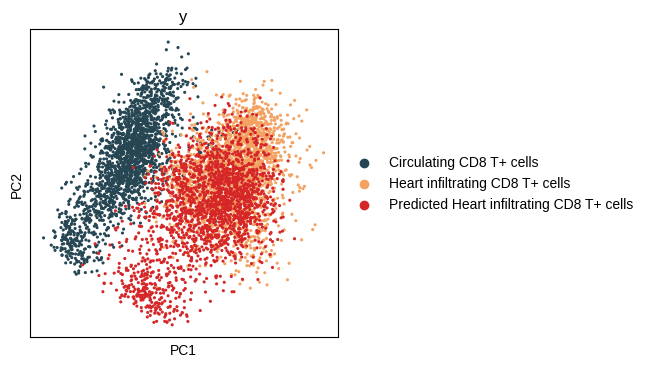

In [20]:
fig, ax = plt.subplots(figsize=(4, 4))

sc.pl.pca(
    concat_subsampled, 
    color='y',
    palette=custom_palette, 
    show=False,
    ax=ax
)

ax.set_aspect('equal')
ax.set_box_aspect(1)

for coll in ax.collections:  # iterates over plotted points
    coll.set_rasterized(True)

plt.savefig(f'{FIG_ROOT}/Myocarditis/PCA.png', dpi=500)
plt.savefig(f'{FIG_ROOT}/Myocarditis/PCA.svg', dpi=400)

# Violinplot

In [21]:
import seaborn as sns

In [22]:
import warnings
warnings.filterwarnings('ignore')

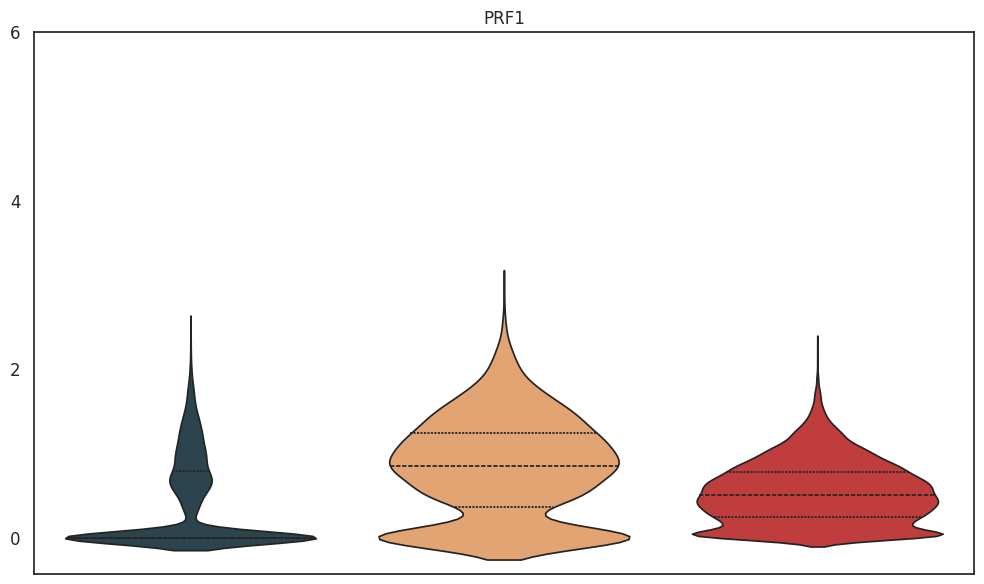

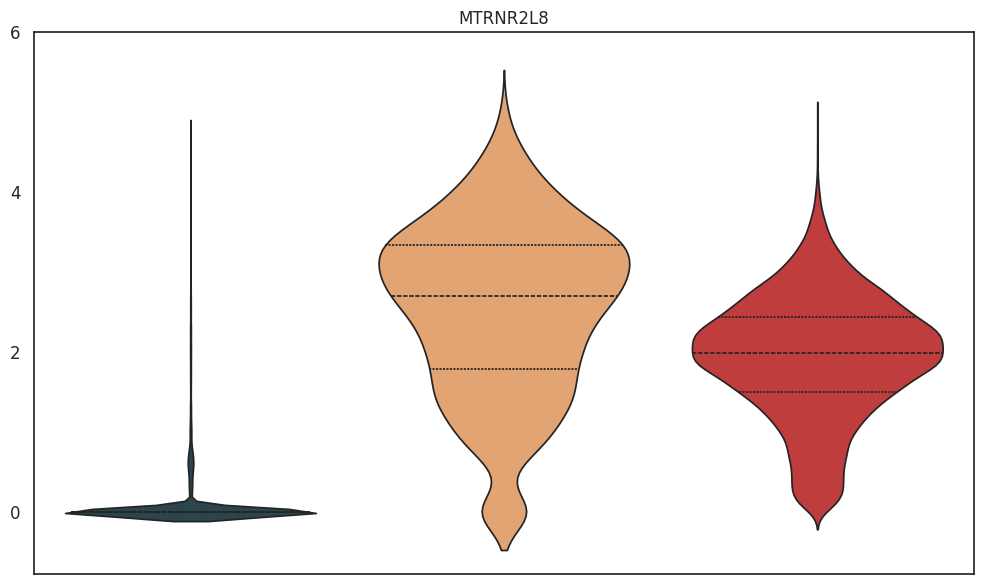

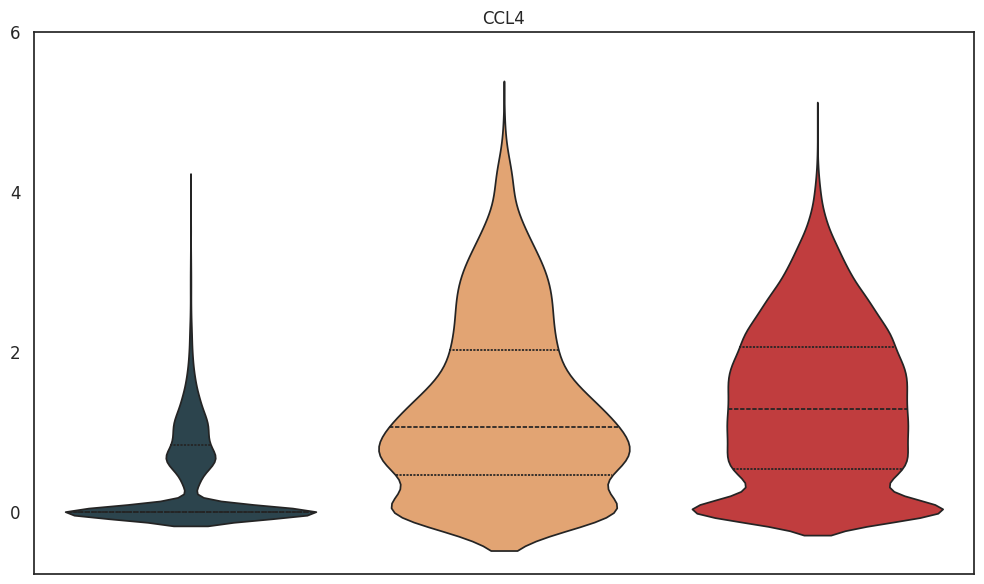

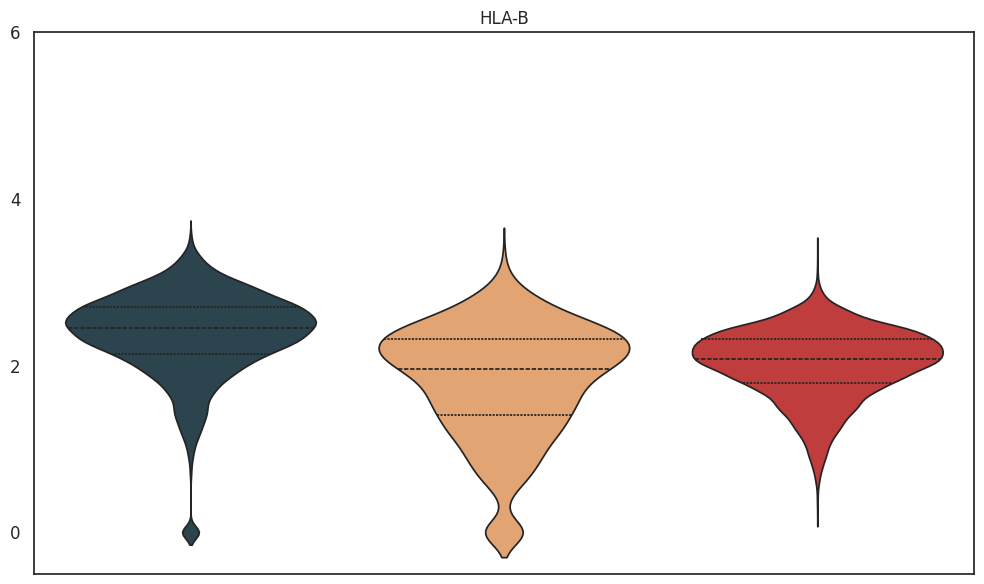

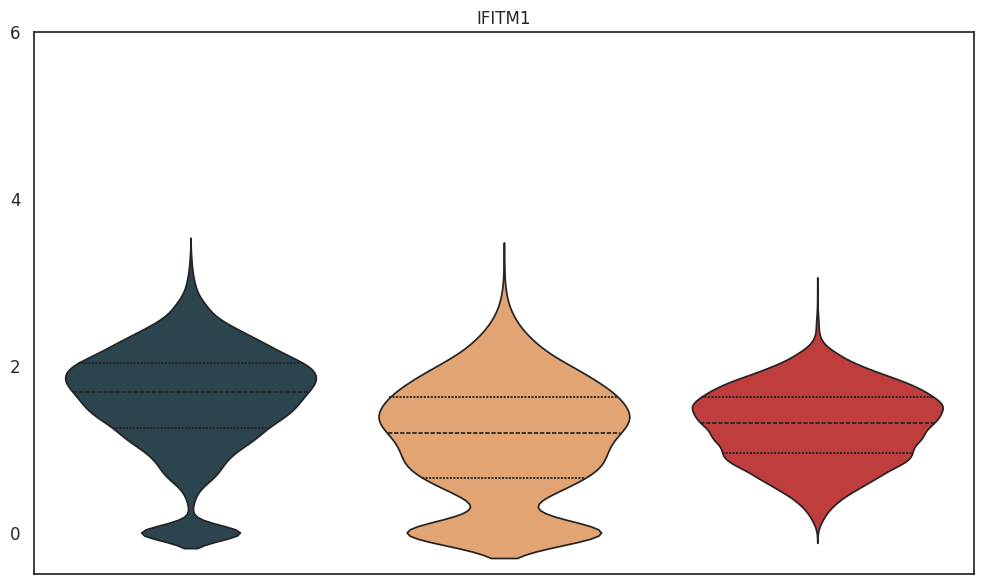

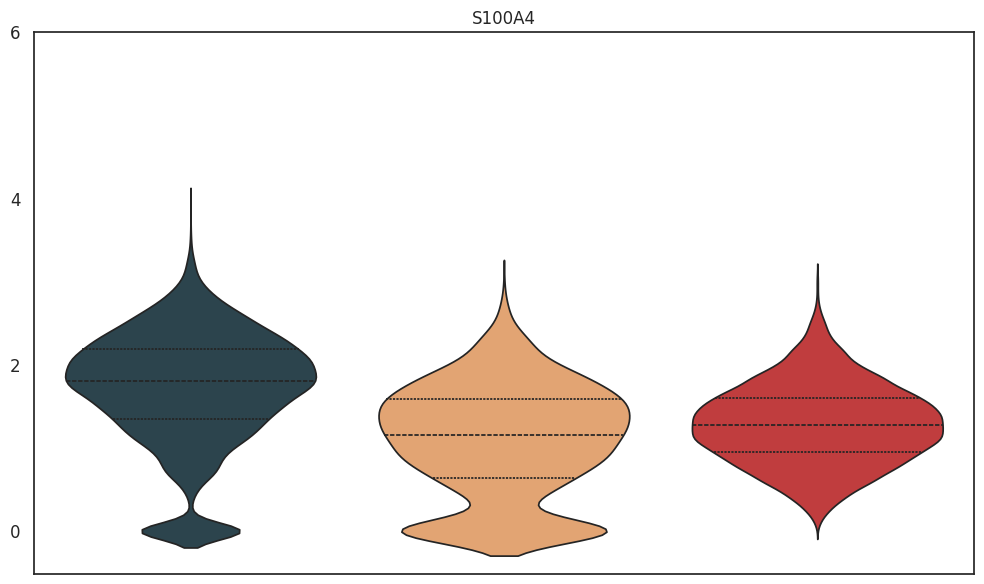

In [23]:
for gene_name in ['PRF1', 'MTRNR2L8', 'CCL4', 'HLA-B', 'IFITM1', 'S100A4']:
    gene_idx = adata_org.var_names.get_loc(gene_name)
    concat.obs['value'] = concat[:, gene_idx].X.toarray().squeeze()
    
    category_order = [
        'Circulating CD8 T+ cells', 
        'Heart infiltrating CD8 T+ cells', 
        'Predicted Heart infiltrating CD8 T+ cells'
    ]

    sns.set(style="white",
            font_scale=1.0,
            rc={
                "axes.titlesize": 12,
                "axes.labelsize": 12,
                "xtick.labelsize": 12,
                "ytick.labelsize": 12,
                "legend.fontsize": 12
            })

    plt.figure(figsize=(10, 6))
    ax = sns.violinplot(
        x="y", 
        y="value", 
        data=concat.obs, 
        inner="quartile", 
        order=category_order, 
        palette=custom_palette,
    )

    # Trim
    #sns.despine(offset=10, trim=True)
    # set common y_max
    ax.set_ylim(top=6)
    ax.set_yticks([0, 2, 4, 6])
    ax.set_xticks([])
    ax.set_title(gene_name, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("", fontsize=12)
   
    ax.grid(False)
    
    plt.tight_layout()
    
    plt.savefig(f'{FIG_ROOT}/Myocarditis/{gene_name}.png', dpi=500)
    plt.savefig(f'{FIG_ROOT}/Myocarditis/{gene_name}.svg', dpi=400)

    del concat.obs['value']